# 🧠 Teen Mental Health & Social Media

## Project Goal
Analyze how teen social media habits, sleep, screen time, physical activity, academic performance, and social interaction relate to mental health indicators such as stress, anxiety, addiction level, and depression label.

This notebook is written for students. Each question has:

- a clear request
- a short explanation
- a full working solution

> Dataset expected in the same folder: `teen_mental_health.csv`

## 0. Imports and Setup

### Request
Import the libraries needed for data analysis and visualization.

### Why we do this
We use `pandas` and `numpy` for data analysis, `matplotlib` and `seaborn` for static charts, and `plotly` for interactive charts.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px


## 1. Load the Dataset

### Request
Read the CSV file into a DataFrame called `df`.

### Why we do this
Before analysis, we need to load the data into Python.

In [2]:
df = pd.read_csv("teen_mental_health.csv")
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,19.0,male,0.1,Both,8.4,0.4,4.00,4.9,medium,0.0,0.0,0.0,0.0
1,16.0,female,1.6,TikTok,7.5,0.8,3.54,5.6,medium,2.0,3.0,2.0,0.0
2,17.0,male,1.9,Instagram,7.4,0.6,4.00,NaN,medium,2.0,4.0,NaN,0.0
3,19.0,male,5.4,Instagram,4.9,3.9,2.61,2.7,low,6.0,4.0,4.0,0.0
4,15.0,male,3.7,Both,4.6,NaN,2.51,3.8,medium,5.0,3.0,1.0,0.0


# Part 1 — Data Understanding

In this part, we inspect the dataset structure, columns, data types, missing values, and basic statistics.

## Q1. Dataset Overview

### Request
Display the shape, column names, first rows, and last rows.

### Why we do this
This gives us a first understanding of the dataset size and available variables.

In [3]:
print("Rows and columns:", df.shape)
print("Column names:")
print(df.columns.tolist())

display(df.head())
display(df.tail())

Rows and columns: (1000, 13)
Column names:
['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,19.0,male,0.1,Both,8.4,0.4,4.00,4.9,medium,0.0,0.0,0.0,0.0
1,16.0,female,1.6,TikTok,7.5,0.8,3.54,5.6,medium,2.0,3.0,2.0,0.0
2,17.0,male,1.9,Instagram,7.4,0.6,4.00,NaN,medium,2.0,4.0,NaN,0.0
3,19.0,male,5.4,Instagram,4.9,3.9,2.61,2.7,low,6.0,4.0,4.0,0.0
4,15.0,male,3.7,Both,4.6,NaN,2.51,3.8,medium,5.0,3.0,1.0,0.0


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
995,18.0,female,3.6,Instagram,5.3,1.8,2.60,4.3,medium,5.0,5.0,4.0,0.0
996,13.0,female,5.5,Both,4.3,2.5,1.96,3.9,medium,7.0,4.0,10.0,NaN
997,19.0,male,7.1,Instagram,NaN,4.5,1.31,2.0,low,5.0,5.0,9.0,0.0
998,16.0,male,5.8,Instagram,5.5,NaN,1.93,3.2,medium,7.0,7.0,8.0,1.0
999,18.0,female,2.9,Instagram,7.8,1.6,3.34,4.5,medium,6.0,3.0,NaN,0.0


## Q2. Clean Column Names

### Request
Convert column names to lowercase and replace spaces or dashes with underscores.

### Why we do this
Clean column names are easier to use in Python.

In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print(df.columns.tolist())

['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']


## Q3. Check Data Types

### Request
Show the data types of all columns.

### Why we do this
Numerical and categorical columns are analyzed differently.

In [5]:
df.dtypes

age                         float64
gender                          str
daily_social_media_hours    float64
platform_usage                  str
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level        str
stress_level                float64
anxiety_level               float64
addiction_level             float64
depression_label            float64
dtype: object

## Q4. Basic Information with `.info()`

### Request
Display detailed dataset information.

### Why we do this
`.info()` shows column types, non-null values, and memory usage.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       961 non-null    float64
 1   gender                    944 non-null    str    
 2   daily_social_media_hours  950 non-null    float64
 3   platform_usage            945 non-null    str    
 4   sleep_hours               940 non-null    float64
 5   screen_time_before_sleep  954 non-null    float64
 6   academic_performance      966 non-null    float64
 7   physical_activity         950 non-null    float64
 8   social_interaction_level  959 non-null    str    
 9   stress_level              936 non-null    float64
 10  anxiety_level             956 non-null    float64
 11  addiction_level           965 non-null    float64
 12  depression_label          952 non-null    float64
dtypes: float64(10), str(3)
memory usage: 101.7 KB


## Q5. Separate Numerical and Categorical Columns

### Request
Create lists for numerical and categorical columns.

### Why we do this
This helps us apply the correct cleaning and analysis methods to each column type.

In [7]:
num_cols = df.select_dtypes(include=["number","float64","int64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "str"]).columns.tolist()

print("Numerical columns:")
print(num_cols)

print("Categorical columns:")
print(cat_cols)

Numerical columns:
['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
Categorical columns:
['gender', 'platform_usage', 'social_interaction_level']


# Part 2 — Data Cleaning

In this part, we check missing values, duplicates, and clean the dataset.

## Q6. Check Missing Values

### Request
Find how many missing values exist in each column.

### Why we do this
Missing values can affect statistics, groups, and visualizations.

In [8]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing_summary.sort_values("missing_count", ascending=False)

,missing_count,missing_percent
stress_level,64,6.4
sleep_hours,60,6.0
gender,56,5.6
platform_usage,55,5.5
daily_social_media_hours,50,5.0
physical_activity,50,5.0
depression_label,48,4.8
screen_time_before_sleep,46,4.6
anxiety_level,44,4.4
social_interaction_level,41,4.1


## Q7. Check Duplicate Rows

### Request
Check how many duplicate rows exist.

### Why we do this
Duplicate rows can make results misleading because the same observation is counted more than once.

In [9]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

df[df.duplicated()].head()

Duplicate rows: 0


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label


## Q8. Remove Duplicate Rows

### Request
Remove duplicate rows from the dataset.

### Why we do this
After removing duplicates, each row represents one unique student record.

In [10]:
before = df.shape[0]

df = df.drop_duplicates().reset_index(drop=True)

after = df.shape[0]

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 1000
Rows after: 1000
Rows removed: 0


## Q9. Fill Missing Numerical Values

### Request
Fill missing numerical values using the median of each numerical column.

### Why we do this
The median is useful because it is less affected by extreme values than the mean.

In [11]:
numeric_medians = df[num_cols].median()
df[num_cols] = df[num_cols].fillna(numeric_medians)

df[num_cols].isna().sum()

age                         0
daily_social_media_hours    0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

## Q10. Fill Missing Categorical Values

### Request
Fill missing categorical values using the most common value of each categorical column.

### Why we do this
For text/category columns, the mode is a simple way to replace missing values.

In [12]:
for col in cat_cols:
    most_common_value = df[col].mode()[0]
    df[col] = df[col].fillna(most_common_value)

print("Total missing values after cleaning:", df.isna().sum().sum())

Total missing values after cleaning: 0


## Q11. Descriptive Statistics

### Request
Display descriptive statistics for numerical columns.

### Why we do this
This shows the minimum, maximum, mean, standard deviation, and quartiles for each numerical variable.

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,15.96700,1.971242,13.0,14.00,16.00,18.0000,19.0
daily_social_media_hours,1000.0,4.03250,1.844146,0.0,2.80,4.10,5.2000,9.9
sleep_hours,1000.0,5.97690,1.146705,3.0,5.20,6.00,6.7000,9.5
screen_time_before_sleep,1000.0,2.38190,1.185110,0.0,1.60,2.40,3.2000,5.0
academic_performance,1000.0,2.64676,0.712379,1.0,2.19,2.67,3.1125,4.0
physical_activity,1000.0,3.94260,1.301076,0.0,3.20,3.90,4.8000,7.8
stress_level,1000.0,4.75500,2.657826,0.0,3.00,5.00,7.0000,10.0
anxiety_level,1000.0,4.48800,2.657615,0.0,3.00,4.00,6.0000,10.0
addiction_level,1000.0,5.21000,2.805311,0.0,3.00,5.00,7.0000,10.0
depression_label,1000.0,0.38500,0.486839,0.0,0.00,0.00,1.0000,1.0


# Part 3 — Feature Engineering

In this part, we create new columns that make the analysis easier and more meaningful.

## Q12. Create Social Media Usage Category

### Request
Create `usage_category` from `daily_social_media_hours`.

### Why we do this
Instead of only using exact hours, we can compare students in Low, Medium, and High usage groups.

In [14]:
def categorize_social_media_usage(hours):
    if hours < 3:
        return "Low"
    elif hours < 6:
        return "Medium"
    else:
        return "High"


df["usage_category"] = df["daily_social_media_hours"].apply(categorize_social_media_usage)

df["usage_category"].value_counts()

usage_category
Medium    573
Low       282
High      145
Name: count, dtype: int64

## Q13. Create Sleep Category

### Request
Create `sleep_category` from `sleep_hours`.

### Why we do this
This helps us compare students with low sleep, healthy sleep, and high sleep.

In [15]:
def categorize_sleep(hours):
    if hours < 7:
        return "Low"
    elif hours <= 9:
        return "Healthy"
    else:
        return "High"


df["sleep_category"] = df["sleep_hours"].apply(categorize_sleep)

df["sleep_category"].value_counts()

sleep_category
Low        796
Healthy    201
High         3
Name: count, dtype: int64

## Q14. Create Mental Risk Score

### Request
Create `risk_score` by adding stress, anxiety, and addiction levels.

### Why we do this
A combined score makes it easier to compare overall mental health risk.

In [16]:
df["risk_score"] = (
    df["stress_level"] +
    df["anxiety_level"] +
    df["addiction_level"]
)

df[["stress_level", "anxiety_level", "addiction_level", "risk_score"]].head()

,stress_level,anxiety_level,addiction_level,risk_score
0,0.0,0.0,0.0,0.0
1,2.0,3.0,2.0,7.0
2,2.0,4.0,5.0,11.0
3,6.0,4.0,4.0,14.0
4,5.0,3.0,1.0,9.0


## Q15. Create Mental Risk Category

### Request
Create `risk_category` from `risk_score`.

### Why we do this
Low, Medium, and High risk groups are easier to compare than raw scores.

In [17]:
def categorize_risk(score):
    if score <= 12:
        return "Low"
    elif score <= 21:
        return "Medium"
    else:
        return "High"


df["risk_category"] = df["risk_score"].apply(categorize_risk)

df["risk_category"].value_counts()

risk_category
Medium    452
Low       392
High      156
Name: count, dtype: int64

## Q16. Create Screen-to-Sleep Ratio

### Request
Create `screen_sleep_ratio` using social media hours, screen time before sleep, and sleep hours.

### Why we do this
This feature compares screen exposure with sleep time. Higher values mean more screen time compared to sleep.

In [18]:
df["screen_sleep_ratio"] = (
    df["daily_social_media_hours"] + df["screen_time_before_sleep"]
) / df["sleep_hours"].replace(0, np.nan)

df["screen_sleep_ratio"] = df["screen_sleep_ratio"].fillna(
    df["screen_sleep_ratio"].median()
)

df[[
    "daily_social_media_hours",
    "screen_time_before_sleep",
    "sleep_hours",
    "screen_sleep_ratio"
]].head()

,daily_social_media_hours,screen_time_before_sleep,sleep_hours,screen_sleep_ratio
0,0.1,0.4,8.4,0.059524
1,1.6,0.8,7.5,0.320000
2,1.9,0.6,7.4,0.337838
3,5.4,3.9,4.9,1.897959
4,3.7,2.4,4.6,1.326087


## Q17. Create Physical Activity Category

### Request
Create `physical_activity_category` from `physical_activity`.

### Why we do this
This helps us compare risk scores between students with low, medium, and high physical activity.

In [19]:
def categorize_activity(value):
    if value <= 3:
        return "Low"
    elif value <= 7:
        return "Medium"
    else:
        return "High"


df["physical_activity_category"] = df["physical_activity"].apply(categorize_activity)

df["physical_activity_category"].value_counts()

physical_activity_category
Medium    765
Low       224
High       11
Name: count, dtype: int64

## Q18. Define Mental Health Score Columns

### Request
Create a list called `score_cols` for the main mental health indicators.

### Why we do this
We will reuse this list in many groupby analyses.

In [20]:
score_cols = [
    "stress_level",
    "anxiety_level",
    "addiction_level",
    "depression_label",
    "risk_score"
]

score_cols

['stress_level',
 'anxiety_level',
 'addiction_level',
 'depression_label',
 'risk_score']

# Part 4 — Exploratory Data Analysis

In this part, we compare groups and look for patterns in the data.

## Q19. Average Mental Health Scores

### Request
Calculate the average value of the main mental health score columns.

### Why we do this
This gives a general overview of the mental health indicators in the dataset.

In [21]:
df[score_cols].mean().sort_values(ascending=False).to_frame("average")

,average
risk_score,14.453
addiction_level,5.210
stress_level,4.755
anxiety_level,4.488
depression_label,0.385


## Q20. Gender-Based Comparison

### Request
Compare average mental health scores by gender.

### Why we do this
This helps us see whether different gender groups have different average stress, anxiety, addiction, depression, or risk values.

In [22]:
gender_summary = df.groupby("gender")[score_cols].mean().round(2)

gender_summary

,stress_level,anxiety_level,addiction_level,depression_label,risk_score
gender,,,,,
female,4.60,4.34,5.13,0.37,14.07
male,4.88,4.61,5.27,0.40,14.77


## Q21. Platform-Based Comparison

### Request
Compare average mental health scores by most-used platform.

### Why we do this
This helps us check whether some platforms are associated with higher average risk scores.

In [23]:
platform_summary = (
    df.groupby("platform_usage")[score_cols]
    .mean()
    .round(2)
    .sort_values("risk_score", ascending=False)
)

platform_summary

,stress_level,anxiety_level,addiction_level,depression_label,risk_score
platform_usage,,,,,
Both,4.89,4.51,5.38,0.38,14.77
TikTok,4.80,4.55,5.09,0.39,14.45
Instagram,4.61,4.43,5.16,0.39,14.20


## Q22. Usage Category vs Mental Health

### Request
Compare mental health scores across Low, Medium, and High social media usage groups.

### Why we do this
This is one of the main questions of the project: do high usage students have higher mental health risk?

In [24]:
usage_order = ["Low", "Medium", "High"]

usage_summary = (
    df.groupby("usage_category")[score_cols]
    .mean()
    .reindex(usage_order)
    .round(2)
)

usage_summary

,stress_level,anxiety_level,addiction_level,depression_label,risk_score
usage_category,,,,,
Low,2.64,2.34,2.75,0.06,7.73
Medium,5.09,4.86,5.61,0.42,15.55
High,7.57,7.18,8.43,0.88,23.18


## Q23. Sleep Category vs Mental Health

### Request
Compare mental health scores across sleep categories.

### Why we do this
This checks whether students with low sleep have higher stress, anxiety, or risk score.

In [25]:
sleep_order = ["Low", "Healthy", "High"]

sleep_summary = (
    df.groupby("sleep_category")[score_cols]
    .mean()
    .reindex(sleep_order)
    .round(2)
)

sleep_summary

,stress_level,anxiety_level,addiction_level,depression_label,risk_score
sleep_category,,,,,
Low,5.30,4.98,5.80,0.47,16.08
Healthy,2.67,2.59,2.93,0.06,8.18
High,1.00,1.67,0.33,0.00,3.00


## Q24. Physical Activity vs Risk

### Request
Compare risk score statistics across physical activity categories.

### Why we do this
This checks whether students with higher physical activity have lower mental health risk.

In [26]:
activity_order = ["Low", "Medium", "High"]

activity_risk = (
    df.groupby("physical_activity_category")["risk_score"]
    .agg(["count", "mean", "median", "std"])
    .reindex(activity_order)
    .round(2)
)

activity_risk

,count,mean,median,std
physical_activity_category,,,,
Low,224,19.48,20.0,5.72
Medium,765,13.10,13.0,6.07
High,11,6.18,5.0,3.84


## Q25. Academic Performance vs Risk Category

### Request
Compare academic performance across risk categories.

### Why we do this
This checks whether high-risk students have lower academic performance on average.

In [27]:
risk_order = ["Low", "Medium", "High"]

academic_summary = (
    df.groupby("risk_category")["academic_performance"]
    .agg(["count", "mean", "median", "std"])
    .reindex(risk_order)
    .round(2)
)

academic_summary

,count,mean,median,std
risk_category,,,,
Low,392,3.15,3.13,0.55
Medium,452,2.49,2.53,0.54
High,156,1.82,1.82,0.52


## Q26. Social Interaction vs Risk Category

### Request
Compare social interaction levels across risk categories.

### Why we do this
This checks whether higher-risk students have lower social interaction.

In [30]:
social_summary = (
    df.groupby("risk_category")["social_interaction_level"]
    .value_counts()
    .reset_index(name="count")
)

social_summary

,risk_category,social_interaction_level,count
0,High,low,88
1,High,medium,68
2,Low,medium,310
3,Low,high,54
4,Low,low,28
5,Medium,medium,331
6,Medium,low,114
7,Medium,high,7


## Q27. Top 10 Highest Addiction Levels

### Request
Show the 10 students with the highest addiction level.

### Why we do this
This helps us inspect extreme cases and understand what high-risk rows look like.

In [31]:
columns_to_show = [
    "age",
    "gender",
    "daily_social_media_hours",
    "platform_usage",
    "sleep_hours",
    "stress_level",
    "anxiety_level",
    "addiction_level",
    "risk_score",
    "risk_category"
]

highest_addiction = df.sort_values("addiction_level", ascending=False)[columns_to_show].head(10)

highest_addiction

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,stress_level,anxiety_level,addiction_level,risk_score,risk_category
970,19.0,male,4.9,Instagram,4.7,5.0,4.0,10.0,19.0,Medium
996,13.0,female,5.5,Both,4.3,7.0,4.0,10.0,21.0,Medium
26,16.0,male,8.7,Both,3.3,10.0,10.0,10.0,30.0,High
962,16.0,male,8.6,TikTok,3.9,5.0,8.0,10.0,23.0,High
46,19.0,male,6.4,Both,6.0,8.0,6.0,10.0,24.0,High
928,17.0,male,4.1,Both,5.3,7.0,5.0,10.0,22.0,High
941,17.0,male,9.4,Both,3.3,10.0,10.0,10.0,30.0,High
948,16.0,male,8.2,Both,3.5,10.0,8.0,10.0,28.0,High
951,14.0,female,7.5,Both,3.0,8.0,10.0,10.0,28.0,High
960,13.0,male,7.0,Instagram,4.7,7.0,10.0,10.0,27.0,High


## Q28. Depression Label Distribution

### Request
Count how many students have each depression label.

### Why we do this
This shows the balance between depression label groups.

In [32]:
depression_summary = pd.DataFrame({
    "count": df["depression_label"].value_counts().sort_index(),
    "percent": (df["depression_label"].value_counts(normalize=True).sort_index() * 100).round(2)
})

depression_summary

,count,percent
depression_label,,
0.0,615,61.5
1.0,385,38.5


## Q29. Depression Rate by Usage Category

### Request
Calculate the depression rate for Low, Medium, and High social media usage groups.

### Why we do this
If `depression_label` is 0/1, its mean can be interpreted as the percentage of students labeled with depression risk.

In [33]:
depression_by_usage = (
    df.groupby("usage_category")["depression_label"]
    .mean()
    .reindex(usage_order)   # order low medium high
    .mul(100)
    .round(2)
    .to_frame("depression_rate_percent")   #renames columns
)

depression_by_usage

,depression_rate_percent
usage_category,
Low,5.67
Medium,42.06
High,88.28


## Q30. Cross Tab: Usage Category vs Risk Category

### Request
Create a cross-tabulation between social media usage category and risk category.

### Why we do this
A cross-tab shows how many students fall into each combination of usage and risk group.

In [34]:
usage_risk_table = pd.crosstab(df["usage_category"], df["risk_category"])
usage_risk_percent = pd.crosstab(
    df["usage_category"],
    df["risk_category"],
    normalize="index"
) * 100

usage_risk_table = usage_risk_table.reindex(index=usage_order, columns=risk_order)
usage_risk_percent = usage_risk_percent.reindex(index=usage_order, columns=risk_order)

display(usage_risk_table)
display(usage_risk_percent.round(2))

risk_category,Low,Medium,High
usage_category,,,
Low,243,39,0
Medium,149,366,58
High,0,47,98


risk_category,Low,Medium,High
usage_category,,,
Low,86.17,13.83,0.00
Medium,26.00,63.87,10.12
High,0.00,32.41,67.59


# Part 5 — Statistics and Correlation

In this part, we use correlation to check relationships between numerical variables.

## Q31. Correlation Matrix

### Request
Calculate the correlation matrix for numerical columns.

### Why we do this
Correlation helps us understand which numerical variables move together.

In [35]:
num_cols = df.select_dtypes(include="number").columns.tolist()

corr_matrix = df[num_cols].corr()

corr_matrix.round(2)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,risk_score,screen_sleep_ratio
age,1.00,0.03,-0.03,0.01,-0.02,0.00,0.02,-0.01,0.00,0.00,0.01,0.04
daily_social_media_hours,0.03,1.00,-0.76,0.86,-0.82,-0.61,0.65,0.66,0.74,0.59,0.84,0.92
sleep_hours,-0.03,-0.76,1.00,-0.70,0.67,0.50,-0.54,-0.52,-0.60,-0.47,-0.68,-0.85
screen_time_before_sleep,0.01,0.86,-0.70,1.00,-0.76,-0.55,0.61,0.59,0.69,0.55,0.78,0.87
academic_performance,-0.02,-0.82,0.67,-0.76,1.00,0.54,-0.57,-0.57,-0.66,-0.51,-0.74,-0.78
physical_activity,0.00,-0.61,0.50,-0.55,0.54,1.00,-0.43,-0.41,-0.50,-0.38,-0.55,-0.58
stress_level,0.02,0.65,-0.54,0.61,-0.57,-0.43,1.00,0.44,0.52,0.65,0.80,0.62
anxiety_level,-0.01,0.66,-0.52,0.59,-0.57,-0.41,0.44,1.00,0.50,0.65,0.80,0.62
addiction_level,0.00,0.74,-0.60,0.69,-0.66,-0.50,0.52,0.50,1.00,0.46,0.84,0.70
depression_label,0.00,0.59,-0.47,0.55,-0.51,-0.38,0.65,0.65,0.46,1.00,0.72,0.57


## Q32. Strongest Correlations with Risk Score

### Request
Sort variables by their correlation with `risk_score`.

### Why we do this
This helps us identify which variables are most related to the risk score.

In [36]:
risk_corr = (
    corr_matrix["risk_score"]
    .drop("risk_score")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("correlation_with_risk_score")
)

risk_corr

,correlation_with_risk_score
daily_social_media_hours,0.844353
addiction_level,0.837552
stress_level,0.801451
screen_sleep_ratio,0.799605
anxiety_level,0.795743
screen_time_before_sleep,0.781132
academic_performance,-0.740985
depression_label,0.722301
sleep_hours,-0.684867
physical_activity,-0.551057


# Part 6 — Seaborn Visualizations

In this part, we create static visualizations using Seaborn and Matplotlib.

## Q33. Distribution of Daily Social Media Usage

### Request
Create a histogram for daily social media hours.

### Why we do this
This shows how social media usage is distributed among students.

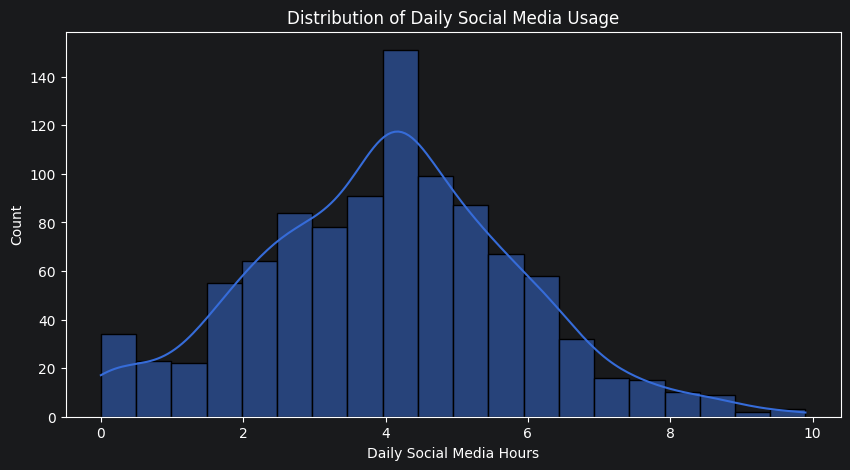

In [37]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="daily_social_media_hours", bins=20, kde=True)
plt.title("Distribution of Daily Social Media Usage")
plt.xlabel("Daily Social Media Hours")
plt.ylabel("Count")
plt.show()

## Q34. Distribution of Sleep Hours

### Request
Create a histogram for sleep hours.

### Why we do this
This shows how many hours students usually sleep.

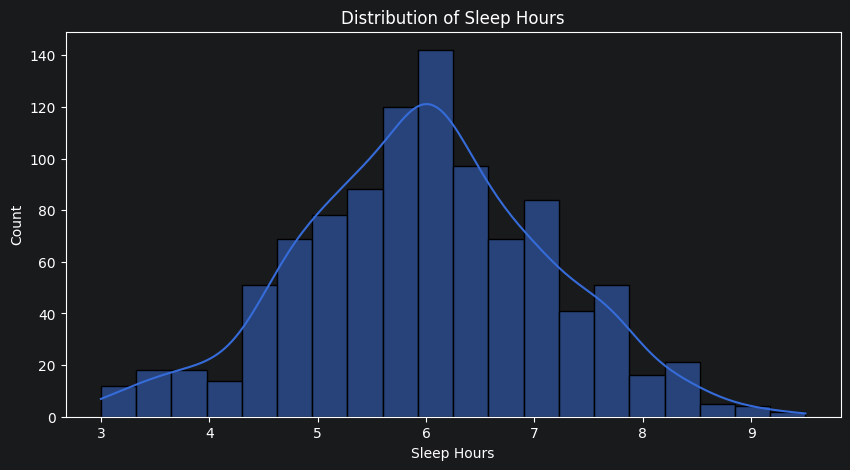

In [38]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="sleep_hours", bins=20, kde=True)
plt.title("Distribution of Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Count")
plt.show()

## Q35. Stress by Usage Category

### Request
Create a boxplot comparing stress level across usage categories.

### Why we do this
Boxplots show median, spread, and possible outliers in each group.

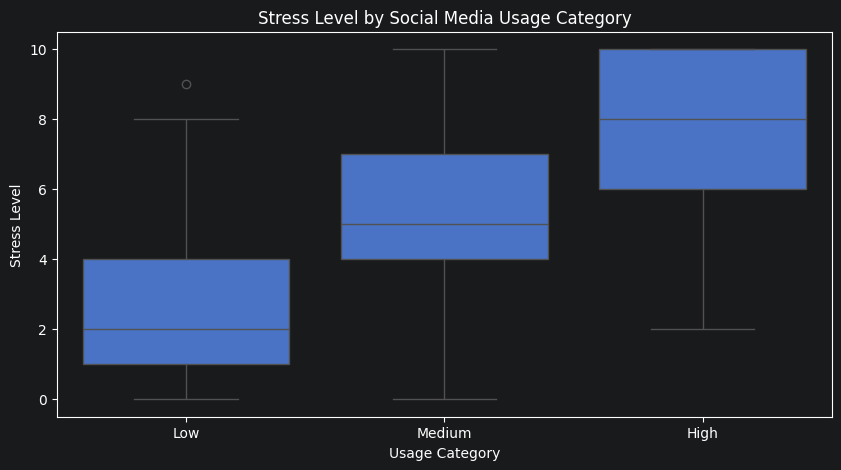

In [39]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="usage_category",
    y="stress_level",
    order=usage_order
)
plt.title("Stress Level by Social Media Usage Category")
plt.xlabel("Usage Category")
plt.ylabel("Stress Level")
plt.show()

## Q36. Anxiety by Sleep Category

### Request
Create a boxplot comparing anxiety level across sleep categories.

### Why we do this
This helps us see whether anxiety differs between low, healthy, and high sleep groups.

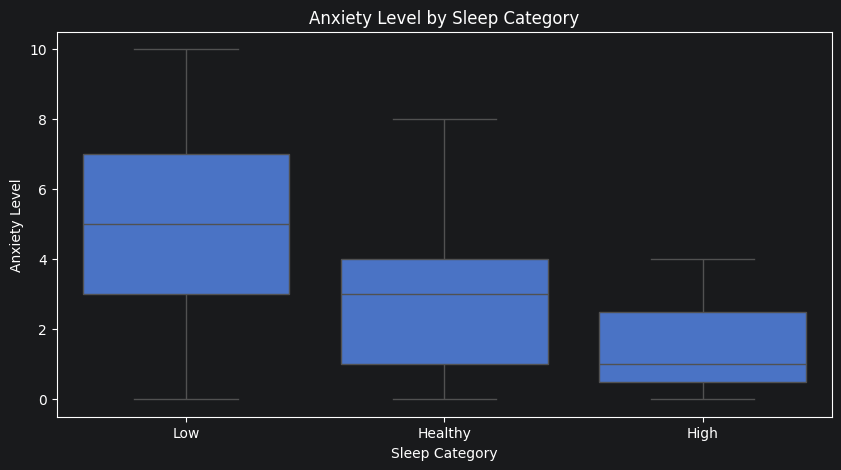

In [40]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="sleep_category",
    y="anxiety_level",
    order=sleep_order
)
plt.title("Anxiety Level by Sleep Category")
plt.xlabel("Sleep Category")
plt.ylabel("Anxiety Level")
plt.show()

## Q37. Average Stress by Platform

### Request
Create a bar chart of average stress by platform.

### Why we do this
This helps compare average stress between platform groups.

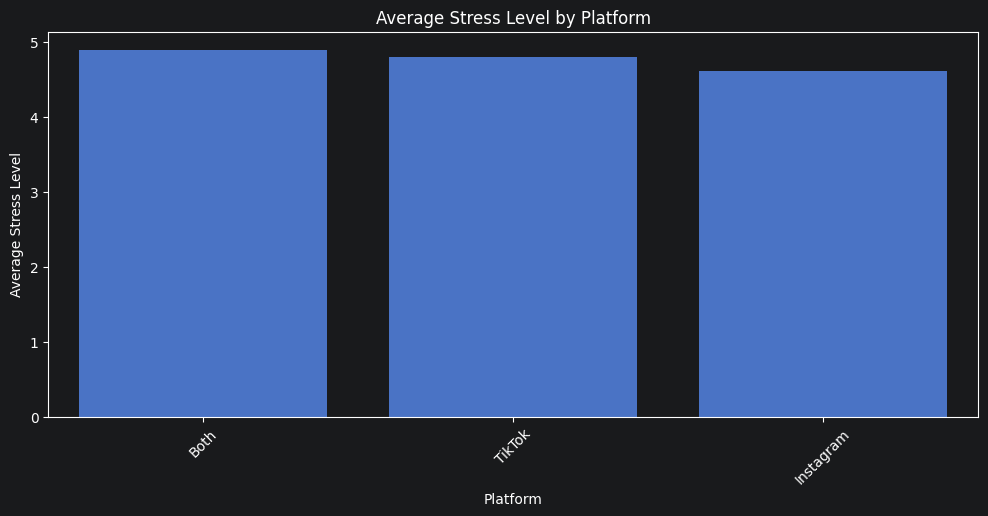

In [41]:
platform_stress = (
    df.groupby("platform_usage", as_index=False)["stress_level"]
    .mean()
    .sort_values("stress_level", ascending=False)
)

plt.figure(figsize=(12, 5))
sns.barplot(data=platform_stress, x="platform_usage", y="stress_level")
plt.title("Average Stress Level by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Stress Level")
plt.xticks(rotation=45)
plt.show()

## Q38. Average Anxiety by Gender

### Request
Create a bar chart of average anxiety by gender.

### Why we do this
This compares average anxiety between gender groups.

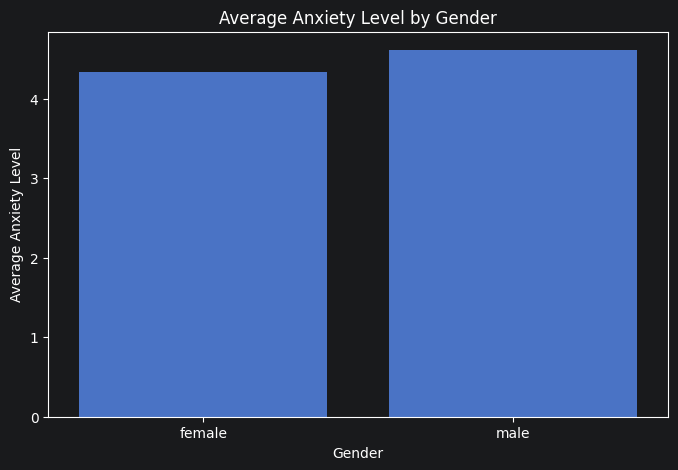

In [42]:
gender_anxiety = df.groupby("gender", as_index=False)["anxiety_level"].mean()

plt.figure(figsize=(8, 5))
sns.barplot(data=gender_anxiety, x="gender", y="anxiety_level")
plt.title("Average Anxiety Level by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Anxiety Level")
plt.show()

## Q39. Social Media Usage vs Stress

### Request
Create a scatter plot between daily social media hours and stress level.

### Why we do this
A scatter plot helps us see whether stress increases as social media hours increase.

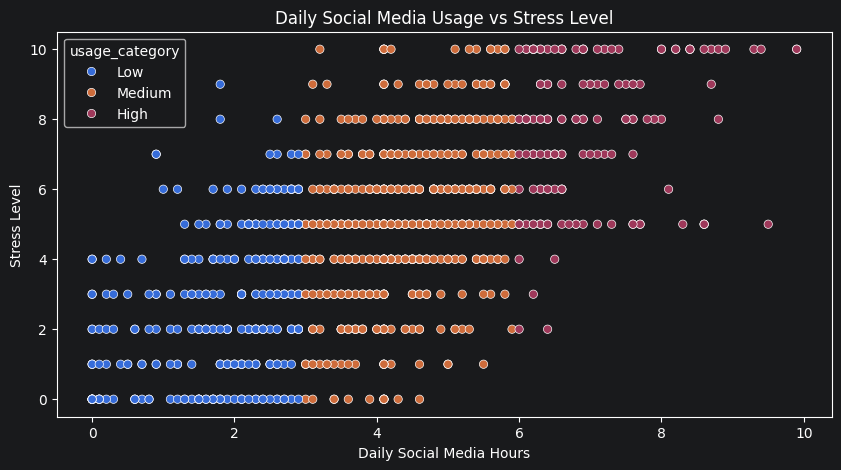

In [43]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="daily_social_media_hours",
    y="stress_level",
    hue="usage_category"
)
plt.title("Daily Social Media Usage vs Stress Level")
plt.xlabel("Daily Social Media Hours")
plt.ylabel("Stress Level")
plt.show()

## Q40. Sleep Hours vs Anxiety

### Request
Create a scatter plot between sleep hours and anxiety level.

### Why we do this
This helps us see whether students with fewer sleep hours tend to have higher anxiety.

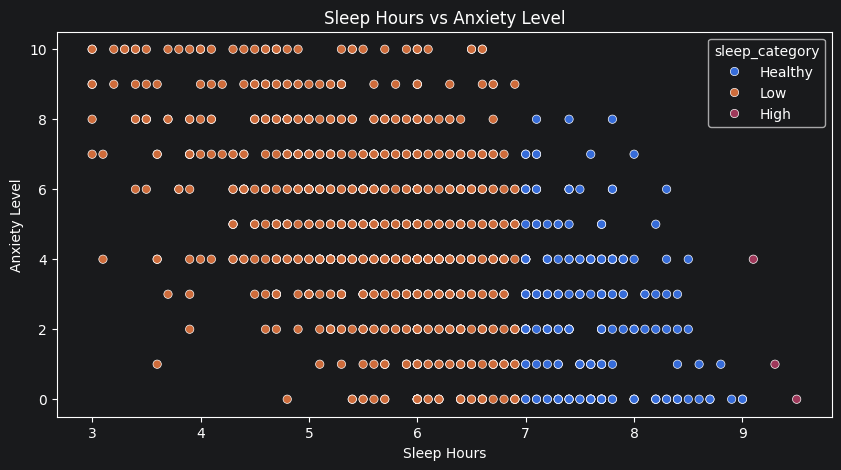

In [44]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="sleep_hours",
    y="anxiety_level",
    hue="sleep_category"
)
plt.title("Sleep Hours vs Anxiety Level")
plt.xlabel("Sleep Hours")
plt.ylabel("Anxiety Level")
plt.show()

## Q41. Correlation Heatmap

### Request
Create a heatmap of the correlation matrix.

### Why we do this
A heatmap makes correlations easier to read visually.

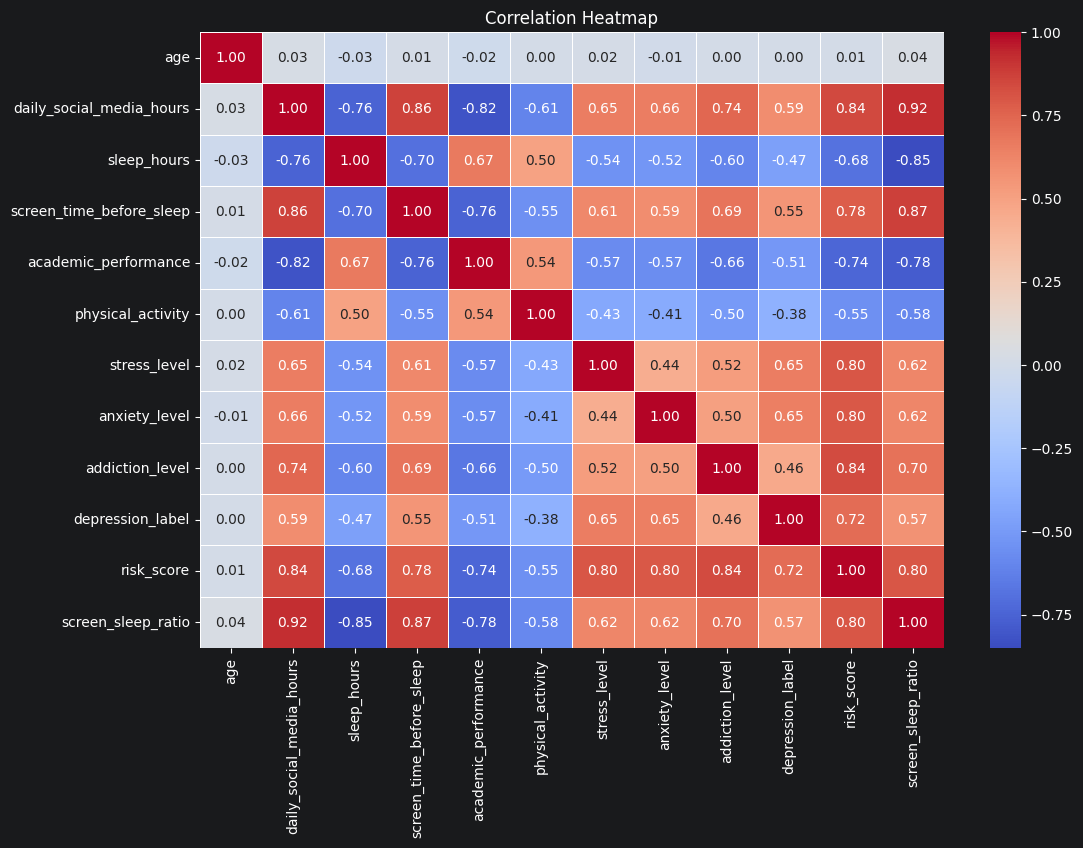

In [45]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Q42. Pairplot for Main Variables

### Request
Create a pairplot for the main numerical variables.

### Why we do this
A pairplot gives a quick visual overview of relationships between several numerical columns.

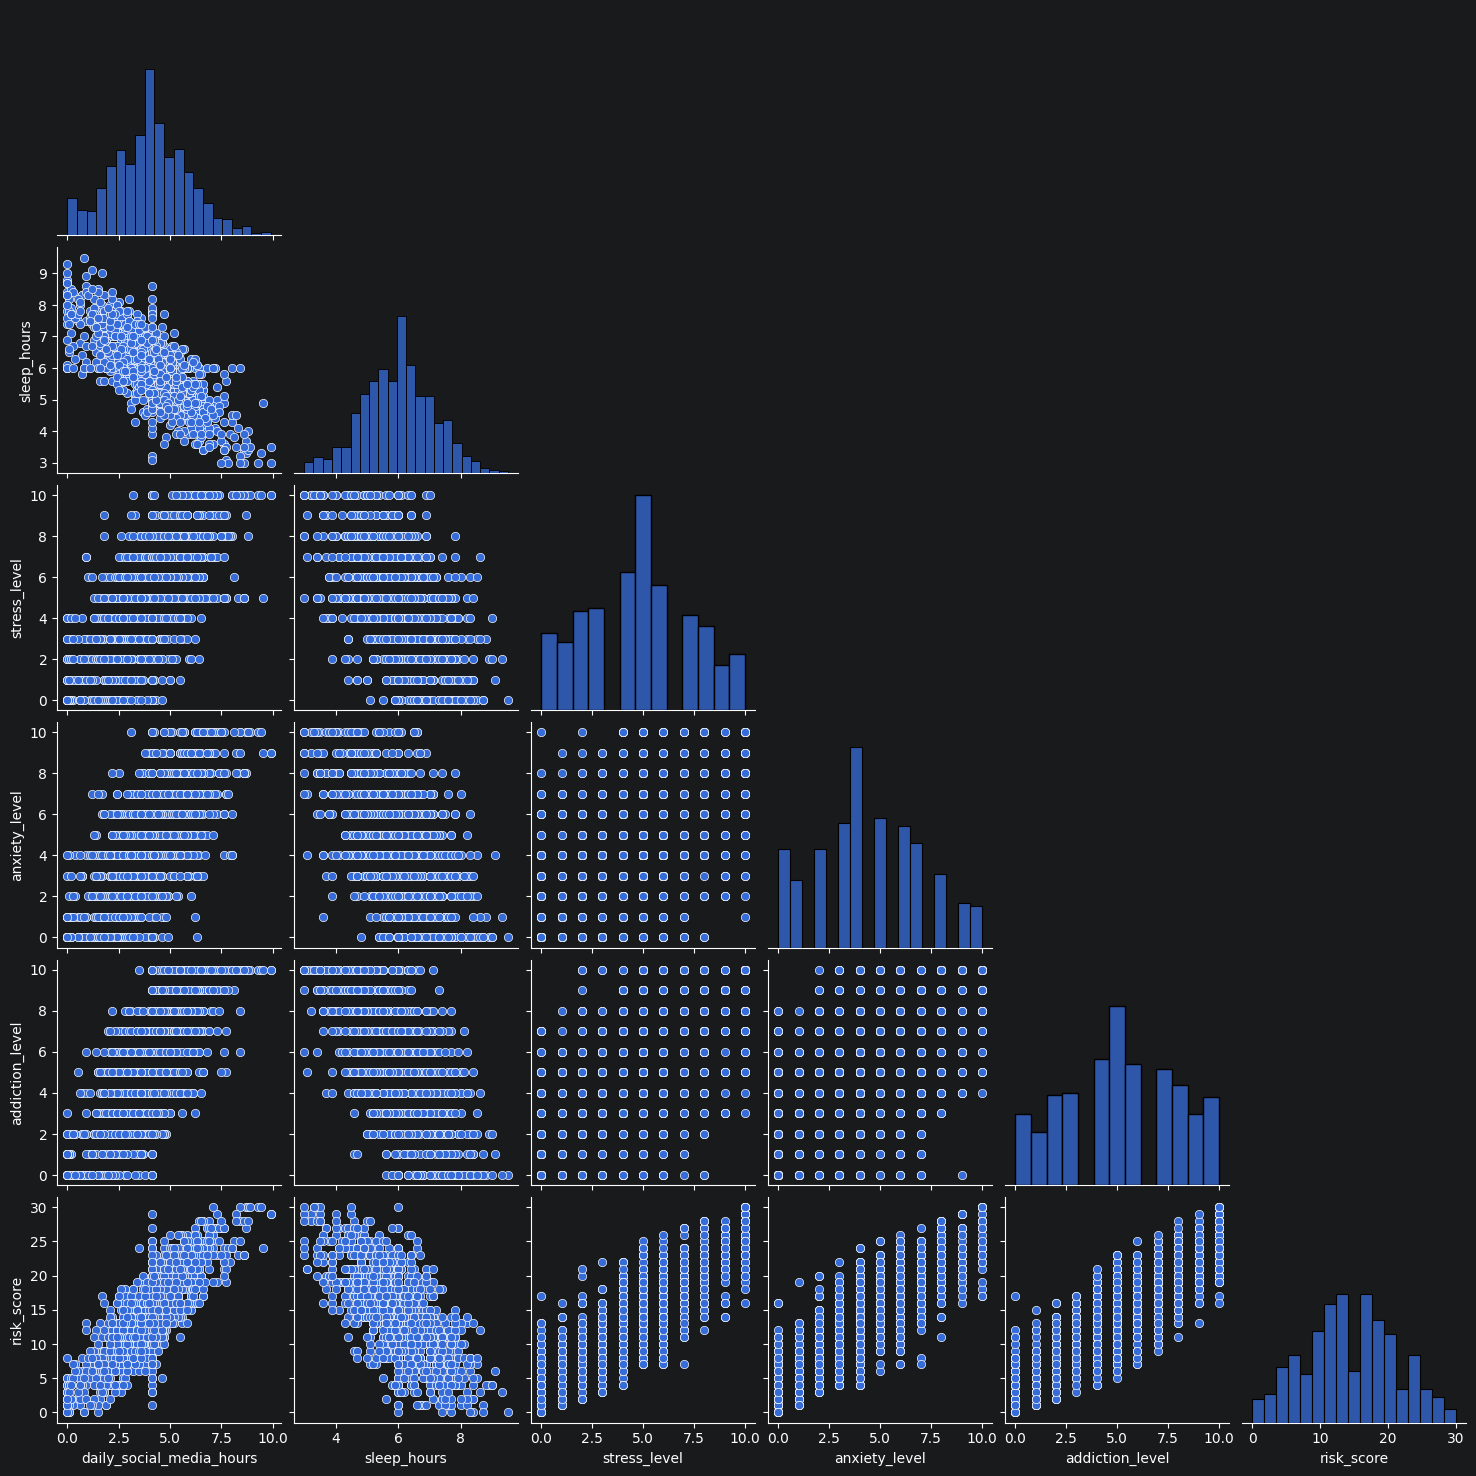

In [46]:
pairplot_cols = [
    "daily_social_media_hours",
    "sleep_hours",
    "stress_level",
    "anxiety_level",
    "addiction_level",
    "risk_score"
]

sns.pairplot(df[pairplot_cols], corner=True)
plt.show()

# Part 7 — Plotly Interactive Visualizations

In this part, we create interactive charts using Plotly.

## Q43. Interactive Scatter: Usage vs Stress

### Request
Create an interactive scatter plot between social media hours and stress level.

### Why we do this
Interactive charts allow us to hover over points and inspect details.

In [47]:
fig = px.scatter(
    df,
    x="daily_social_media_hours",
    y="stress_level",
    color="usage_category",
    hover_data=["age", "gender", "sleep_hours", "risk_score"],
    title="Daily Social Media Usage vs Stress Level"
)

fig.show()

## Q44. Interactive Bar: Average Stress by Platform

### Request
Create an interactive bar chart of average stress by platform.

### Why we do this
This makes it easier to compare platform groups and hover over exact values.

In [48]:
fig = px.bar(
    platform_stress,
    x="platform_usage",
    y="stress_level",
    title="Average Stress Level by Platform",
    text="stress_level"
)

fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")
fig.show()

## Q45. Interactive Boxplot: Anxiety by Sleep Category

### Request
Create an interactive boxplot of anxiety by sleep category.

### Why we do this
This helps compare distribution, median, and outliers interactively.

In [49]:
fig = px.box(
    df,
    x="sleep_category",
    y="anxiety_level",
    category_orders={"sleep_category": sleep_order},
    title="Anxiety Level by Sleep Category"
)

fig.show()

## Q46. Interactive Heatmap: Usage Category vs Risk Category

### Request
Create an interactive heatmap from the cross-tab table.

### Why we do this
The heatmap shows which usage-risk combinations are most common.

In [50]:
heatmap_data = pd.crosstab(df["usage_category"], df["risk_category"])
heatmap_data = heatmap_data.reindex(index=usage_order, columns=risk_order)

fig = px.imshow(
    heatmap_data,
    text_auto=True,
    title="Usage Category vs Risk Category",
    labels=dict(x="Risk Category", y="Usage Category", color="Count")
)

fig.show()

# Part 8 — Final Analysis Questions

Answer these in markdown cells using your tables and charts.

## Q47. Final Insights

### Request
Write 5 insights from your analysis.

### Example answer structure
1. Students with high social media usage had higher/lower average risk score than low usage students.
2. Sleep category showed a visible difference in anxiety or stress levels.
3. Physical activity appeared to be related/not related to risk score.
4. Some platforms had higher average stress levels than others.
5. The strongest correlations with risk score were found in specific mental health or behavior columns.

---

## Q48. Social Media Usage Conclusion

### Request
Does high social media usage appear related to higher mental health risk in this dataset?

### Short explanation
Use grouped means, boxplots, scatter plots, and correlation results to support your answer.

---

## Q49. Sleep Conclusion

### Request
Does sleep appear related to anxiety or stress?

### Short explanation
Use sleep category summaries, scatter plots, and boxplots to explain.

---

## Q50. Physical Activity Conclusion

### Request
Does physical activity appear related to lower risk score?

### Short explanation
Use the physical activity summary table and compare the mean risk scores.

---

## Q51. Dataset Limitation

### Request
Write at least 3 limitations of this dataset.

### Example limitations
- The dataset may be synthetic or survey-based.
- Correlation does not prove causation.
- Self-reported answers can be biased.
- Important variables may be missing, such as family history, school pressure, or clinical diagnosis.

---

## Q52. Improvement Ideas

### Request
Suggest how this analysis could be improved.

### Example ideas
- Collect more real-world data.
- Add more detailed lifestyle and school pressure variables.
- Compare results by age groups.
- Use better-defined clinical labels.
- Repeat the analysis on multiple datasets.